# FILTERING

## Apa Itu Filter?
Filter dalam pengolahan citra digital adalah operasi yang memodifikasi nilai intensitas piksel berdasarkan piksel-piksel di sekitarnya.
Tujuannya bisa bermacam-macam — mulai dari memperhalus citra (smoothing), menajamkan detail (sharpening), hingga menonjolkan tepi (edge detection).

Secara umum, setiap filter bekerja dengan prinsip:

<center><img style="text-align:center" src="img/convolution_formula.png"></center>

Hasil gambar yang difilter (Y) dari gambar asal (X) dan filter dengan kernel (H)

## Konvolusi
Konvolusi merupakan operasi dasar dalam pengolahan citra digital yang digunakan untuk menerapkan berbagai jenis filter seperti blur, sharpen, maupun edge detection. Secara sederhana, konvolusi adalah proses menggabungkan dua fungsi — yaitu citra dan filter — untuk menghasilkan citra baru yang telah dimodifikasi.

Pada rumus dasar sebelumnya, konvolusi dari dua fungsi H dan X didefinisikan sebagai:

<center><img style="text-align:center" src="img/convolution_detail_formulas.png"></center>

setiap titik citra pada posisi (𝑇𝑥,𝑇𝑦), nilai piksel hasil konvolusi dihitung dengan mengalikan setiap elemen filter H(x,y) dengan nilai piksel citra X di posisi yang bersesuaian, kemudian menjumlahkan seluruh hasil perkalian tersebut.

Dengan kata lain, konvolusi bekerja dengan cara menggeser filter ke seluruh bagian citra, lalu menghitung hasil perkalian elemen demi elemen (disebut dot product) antara nilai filter dan area citra yang diliputi oleh filter tersebut.

𝐻(𝑥,𝑦) adalah nilai dari elemen filter atau kernel pada posisi (x, y).

𝑋(𝑇𝑥−𝑥,𝑇𝑦−𝑦) adalah nilai piksel citra yang dikalikan dengan elemen filter pada posisi yang sesuai.

Simbol ∑𝑦∑𝑥 menunjukkan bahwa semua hasil perkalian dijumlahkan untuk menghasilkan satu nilai keluaran di titik  (𝑇𝑥,𝑇𝑦)

Bagian  (𝑇𝑥−𝑥,𝑇𝑦−𝑦) menunjukkan bahwa filter dibalik secara horizontal dan vertikal sebelum digunakan.
Inilah yang membedakan konvolusi murni dari korelasi.
Jika filter tidak dibalik, operasi yang terjadi sebenarnya adalah korelasi, bukan konvolusi.


# FFT (Fast Fourier Transform)
FFT (Fast Fourier Transform) pada gambar digital adalah proses untuk mengubah representasi gambar dari domain spasial (ruang) menjadi domain frekuensi.

Kalau di domain spasial kita melihat gambar sebagai kumpulan nilai intensitas piksel (misalnya terang–gelap di tiap titik), maka di domain frekuensi kita melihat gambar sebagai kombinasi gelombang sinusoidal dengan berbagai frekuensi dan amplitudo yang, jika digabungkan, akan membentuk gambar tersebut.

<div style="font-family:system-ui, -apple-system, Segoe UI, Roboto, Inter; line-height:1.6; color:#222;">

  <h2 style="margin-top:0;">FFT pada Gambar: Fungsi dan Cara Menganalisis</h2>

  <h3>1. Konsep Dasar</h3>
  <p>
    Gambar digital dapat dipandang sebagai fungsi dua dimensi <em>f(x, y)</em> di domain spasial.
    <strong>Fast Fourier Transform</strong> mengubahnya menjadi representasi domain frekuensi <em>F(u, v)</em>.
    Frekuensi rendah merepresentasikan perubahan yang lambat atau area halus, sedangkan frekuensi tinggi merepresentasikan tepi dan detail halus.
  </p>

  <h3>2. Fungsi Utama FFT dalam Pengolahan Citra</h3>
  <ul>
    <li><strong>Transformasi ke domain frekuensi</strong> sehingga kita dapat melihat sebaran energi berdasarkan frekuensi.</li>
    <li><strong>Analisis struktur dan pola</strong> seperti halus atau kasar, acak atau berulang, serta arah dominan suatu tekstur.</li>
  </ul>

  <h3>3. Cara Membaca Spektrum FFT</h3>
  <table style="width:100%; border-collapse:collapse;">
    <thead>
      <tr>
        <th style="text-align:left; border-bottom:2px solid #ddd; padding:8px;">Bagian Spektrum</th>
        <th style="text-align:left; border-bottom:2px solid #ddd; padding:8px;">Makna</th>
        <th style="text-align:left; border-bottom:2px solid #ddd; padding:8px;">Ciri Visual</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding:8px; border-bottom:1px solid #eee;">Pusat</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Frekuensi rendah, menyimpan informasi global dan gradien halus</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Area terang di tengah setelah <code>fftshift</code></td>
      </tr>
      <tr>
        <td style="padding:8px; border-bottom:1px solid #eee;">Pinggiran</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Frekuensi tinggi, menyimpan tepi dan detail halus</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Titik atau pola terang di tepi kanvas spektrum</td>
      </tr>
      <tr>
        <td style="padding:8px; border-bottom:1px solid #eee;">Arah pola</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Orientasi dominan tekstur atau garis pada gambar</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Garis terang yang saling berhadapan sesuai orientasi</td>
      </tr>
      <tr>
        <td style="padding:8px; border-bottom:1px solid #eee;">Simetri</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Citra real menghasilkan spektrum yang simetris</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Kiri dan kanan serta atas dan bawah tampak sebagai cerminan</td>
      </tr>
    </tbody>
  </table>

  <h3>4. Contoh Analisis Kasus Visual</h3>
  <ul>
    <li><strong>Gambar halus</strong> seperti langit atau wajah: pusat sangat terang, pinggir cenderung gelap karena dominasi frekuensi rendah.</li>
    <li><strong>Gambar penuh tepi</strong> seperti tulisan atau rambut: banyak komponen terang di pinggir yang menandakan frekuensi tinggi berlimpah.</li>
    <li><strong>Gambar bertekstur atau periodik</strong> seperti kain bermotif: muncul pola teratur di spektrum yang menandakan periodisitas.</li>
  </ul>

  <h3>5. Fungsi Analisis FFT untuk Tugas Praktis</h3>
  <table style="width:100%; border-collapse:collapse;">
    <thead>
      <tr>
        <th style="text-align:left; border-bottom:2px solid #ddd; padding:8px;">Tujuan Analisis</th>
        <th style="text-align:left; border-bottom:2px solid #ddd; padding:8px;">Penjelasan</th>
        <th style="text-align:left; border-bottom:2px solid #ddd; padding:8px;">Contoh Aplikasi</th>
      </tr>
    </thead>
    <tbody>
      <tr>
        <td style="padding:8px; border-bottom:1px solid #eee;">Identifikasi frekuensi dominan</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Mengukur proporsi energi rendah dibanding energi tinggi</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Klasifikasi tekstur atau penilaian kualitas gambar</td>
      </tr>
      <tr>
        <td style="padding:8px; border-bottom:1px solid #eee;">Analisis orientasi pola</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Menentukan arah perubahan dominan pada struktur</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Deteksi arah serat, retakan, atau pola kisi</td>
      </tr>
      <tr>
        <td style="padding:8px; border-bottom:1px solid #eee;">Kompresi serta penyaringan</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Mengurangi frekuensi tinggi yang kurang penting secara visual</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Kompresi citra dan denoising</td>
      </tr>
      <tr>
        <td style="padding:8px; border-bottom:1px solid #eee;">Analisis ketajaman</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Frekuensi tinggi menunjukkan detail serta ketajaman</td>
        <td style="padding:8px; border-bottom:1px solid #eee;">Penilaian fokus kamera dan mikroskop</td>
      </tr>
    </tbody>
  </table>

  <h3>6. Tips Membaca Spektrum dengan Baik</h3>
  <ul>
    <li>Gunakan <code>fftshift</code> agar komponen nol berada di tengah sehingga mudah dianalisis.</li>
    <li>Tampilkan magnitude dalam skala logaritmik menggunakan <code>log(1 + |F|)</code> agar rentang dinamis terlihat jelas.</li>
    <li>Amati pola simetri dan arah garis terang untuk memahami orientasi tekstur.</li>
    <li>Bandingkan beberapa gambar dengan jenis konten yang berbeda untuk melihat perbedaan sidik jari frekuensi.</li>
    <li>Verifikasi pemahaman dengan melakukan inverse FFT setelah menahan atau menghilangkan rentang frekuensi tertentu.</li>
  </ul>

  <h3>7. Ringkasan Intuitif</h3>
  <p>
    FFT adalah kacamata frekuensi yang menampilkan ritme perubahan pada gambar.
    Pusat spektrum menyimpan bentuk global sementara pinggiran menyimpan tepi dan detail.
    Dengan membaca pola terang, arah, dan sebaran energi, kita dapat menilai karakter gambar secara kuantitatif dan kualitatif.
  </p>

</div>


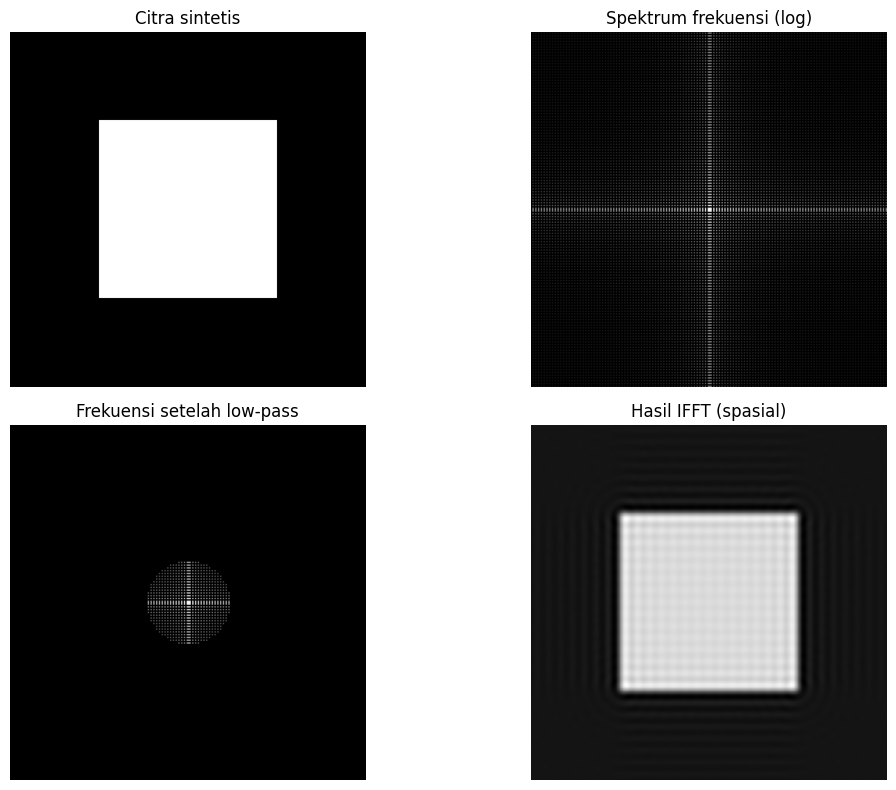

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, fftshift, ifft2

# Buat citra sintetis: kotak putih di tengah, ukuran 256x256
N = 256
image = np.zeros((N, N), dtype=float)
image[64:192, 64:192] = 1.0  # kotak

# FFT 2D
F = fft2(image)
F_shift = fftshift(F)
magnitude = np.log1p(np.abs(F_shift))

# Contoh low-pass sederhana di domain frekuensi
R = 30  # radius cutoff
yy, xx = np.ogrid[:N, :N]
cy, cx = N//2, N//2
mask = (yy - cy)**2 + (xx - cx)**2 <= R**2
F_lp = F_shift * mask
lp_image = np.real(ifft2(fftshift(F_lp)))

# Visualisasi
plt.figure(figsize=(12,8))
plt.subplot(2,2,1); plt.imshow(image, cmap='gray'); plt.title("Citra sintetis"); plt.axis('off')
plt.subplot(2,2,2); plt.imshow(magnitude, cmap='gray'); plt.title("Spektrum frekuensi (log)"); plt.axis('off')
plt.subplot(2,2,3); plt.imshow(np.log1p(np.abs(F_lp)), cmap='gray'); plt.title("Frekuensi setelah low-pass"); plt.axis('off')
plt.subplot(2,2,4); plt.imshow(lp_image, cmap='gray'); plt.title("Hasil IFFT (spasial)"); plt.axis('off')
plt.tight_layout(); plt.show()


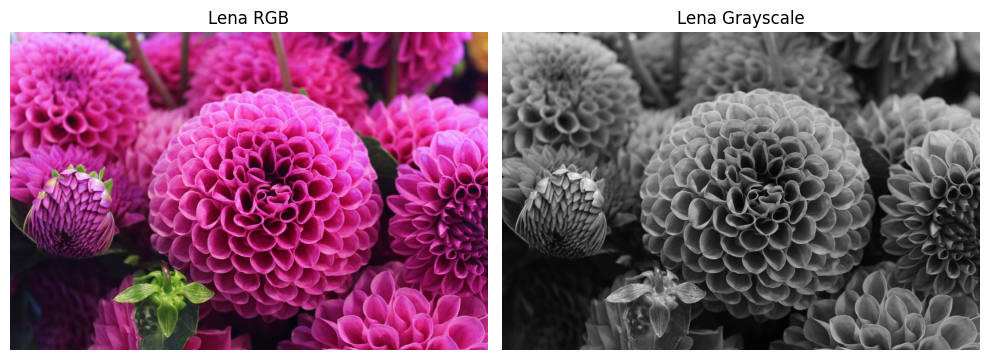

In [1]:
import cv2
import matplotlib.pyplot as plt

# 1) Load BGR, ubah ke RGB biar konsisten dengan Matplotlib
bgr = cv2.imread("91.jpg", cv2.IMREAD_UNCHANGED)

if bgr is None:
    raise FileNotFoundError("File 'lena.png' tidak ditemukan di direktori kerja saat ini.")

# Jika ada alfa, pisahkan dulu
if bgr.shape[-1] == 4:
    bgr, alpha = bgr[...,:3], bgr[...,3]
    
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_f = rgb.astype("float32")/255.0

# 2) Grayscale manual supaya konsisten dengan opsi A
R, G, B = rgb_f[...,0], rgb_f[...,1], rgb_f[...,2]
gray = 0.299*R + 0.587*G + 0.114*B

# 3) Visualisasi
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(rgb_f); plt.title("Lena RGB"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(gray, cmap="gray"); plt.title("Lena Grayscale"); plt.axis("off")
plt.tight_layout(); plt.show()


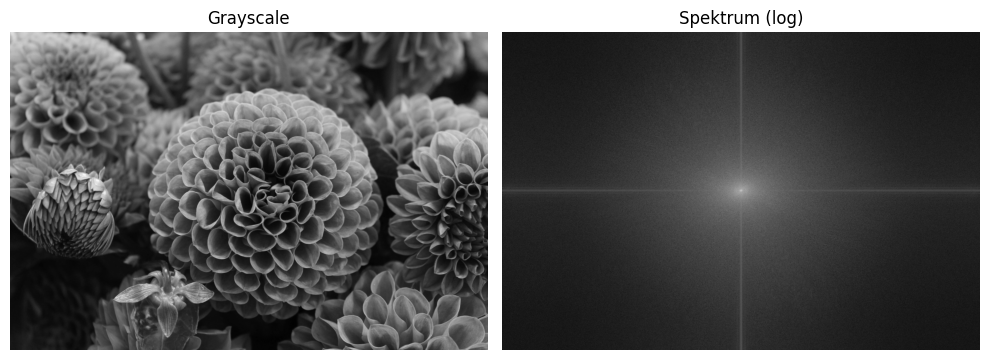

In [2]:
import numpy as np
from numpy.fft import fft2, fftshift

F = fft2(gray)                    # FFT 2D
F_shift = fftshift(F)             # pusatkan DC di tengah
spec = np.log1p(np.abs(F_shift))  # magnitude dalam log scale

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(gray, cmap="gray"); plt.title("Grayscale"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(spec, cmap="gray"); plt.title("Spektrum (log)"); plt.axis("off")
plt.tight_layout(); plt.show()


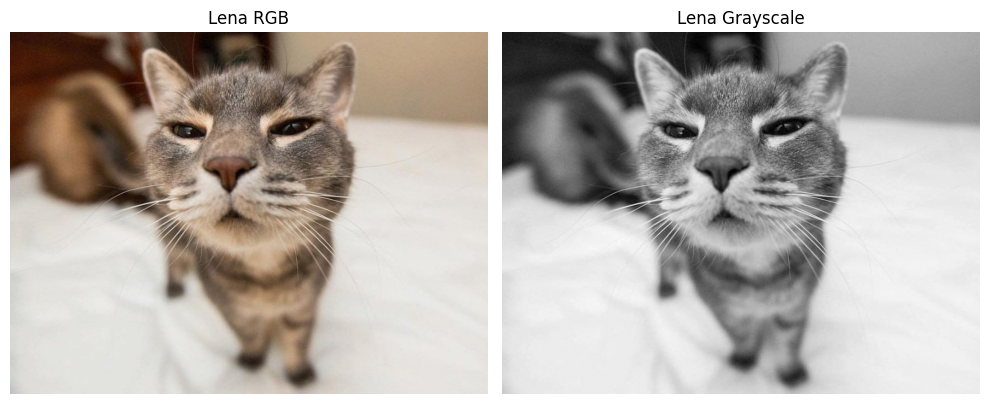

In [4]:
import cv2
import matplotlib.pyplot as plt

# 1) Load BGR, ubah ke RGB biar konsisten dengan Matplotlib
bgr = cv2.imread("01.jpg", cv2.IMREAD_UNCHANGED)

if bgr is None:
    raise FileNotFoundError("File 'lena.png' tidak ditemukan di direktori kerja saat ini.")

# Jika ada alfa, pisahkan dulu
if bgr.shape[-1] == 4:
    bgr, alpha = bgr[...,:3], bgr[...,3]
    
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
rgb_f = rgb.astype("float32")/255.0

# 2) Grayscale manual supaya konsisten dengan opsi A
R, G, B = rgb_f[...,0], rgb_f[...,1], rgb_f[...,2]
gray = 0.299*R + 0.587*G + 0.114*B

# 3) Visualisasi
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(rgb_f); plt.title("Lena RGB"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(gray, cmap="gray"); plt.title("Lena Grayscale"); plt.axis("off")
plt.tight_layout(); plt.show()


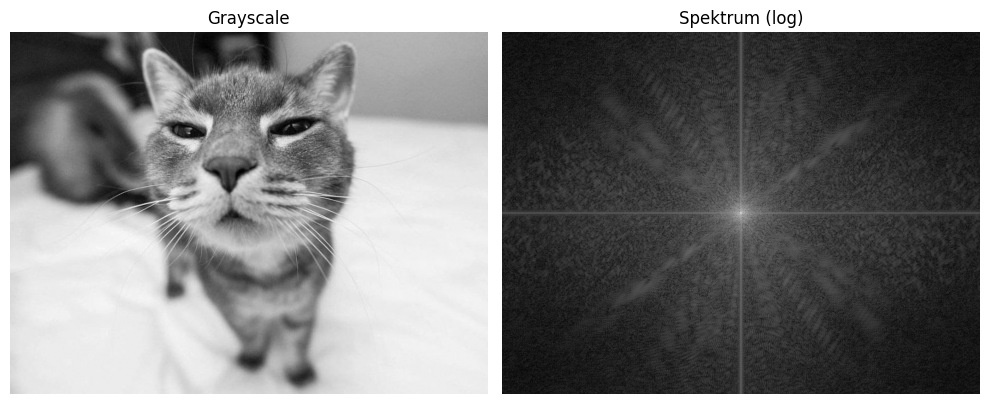

In [5]:
import numpy as np
from numpy.fft import fft2, fftshift

F = fft2(gray)                    # FFT 2D
F_shift = fftshift(F)             # pusatkan DC di tengah
spec = np.log1p(np.abs(F_shift))  # magnitude dalam log scale

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(gray, cmap="gray"); plt.title("Grayscale"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(spec, cmap="gray"); plt.title("Spektrum (log)"); plt.axis("off")
plt.tight_layout(); plt.show()


In [6]:
import numpy as np

# Matriks sesuai gambar
H = np.array([[1, 1, 1],
              [1, 4, 1],
              [1, 1, 1]], dtype=np.int64)   # kernel 3x3

X = np.array([[1, 0, 0, 0],
              [1, 1, 1, 0],
              [1, 1, 1, 0],
              [1, 0, 0, 0]], dtype=np.int64)  # citra 4x4

# Konvolusi 2D manual: definisi matematis (membalik kernel)
def conv2_valid(img, kernel):
    kh, kw = kernel.shape
    Hh, Hw = img.shape
    kflip = kernel[::-1, ::-1]
    out = np.zeros((Hh - kh + 1, Hw - kw + 1), dtype=np.int64)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            window = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kflip)
    return out

def conv2_same(img, kernel, pad_mode="constant"):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    imgp = np.pad(img, ((ph, ph), (pw, pw)), mode=pad_mode)
    return conv2_valid(imgp, kernel)

def conv2_full(img, kernel):
    kh, kw = kernel.shape
    imgp = np.pad(img, ((kh-1, kh-1), (kw-1, kw-1)), mode="constant")
    return conv2_valid(imgp, kernel)

# Hitung tiga mode ukuran keluaran
Y_valid = conv2_valid(X, H)
Y_same  = conv2_same(X, H)                 # zero padding
Y_full  = conv2_full(X, H)

print("Input X:\n", X)
print("\nKernel H:\n", H)

print("\nOutput VALID (2x2):\n", Y_valid)
print("\nOutput SAME  (4x4, zero padding):\n", Y_same)
print("\nOutput FULL  (6x6):\n", Y_full)

# Jika ingin membandingkan dengan korelasi 2D
def corr2_valid(img, kernel):
    kh, kw = kernel.shape
    Hh, Hw = img.shape
    out = np.zeros((Hh - kh + 1, Hw - kw + 1), dtype=np.int64)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            window = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kernel)
    return out

C_valid = corr2_valid(X, H)
print("\nKorelasi VALID:\n", C_valid, "\n(untuk kernel simetris seperti H nilainya sama dengan konvolusi)")


Input X:
 [[1 0 0 0]
 [1 1 1 0]
 [1 1 1 0]
 [1 0 0 0]]

Kernel H:
 [[1 1 1]
 [1 4 1]
 [1 1 1]]

Output VALID (2x2):
 [[10  7]
 [10  7]]

Output SAME  (4x4, zero padding):
 [[ 6  4  2  1]
 [ 8 10  7  2]
 [ 8 10  7  2]
 [ 6  4  2  1]]

Output FULL  (6x6):
 [[ 1  1  1  0  0  0]
 [ 2  6  4  2  1  0]
 [ 3  8 10  7  2  0]
 [ 3  8 10  7  2  0]
 [ 2  6  4  2  1  0]
 [ 1  1  1  0  0  0]]

Korelasi VALID:
 [[10  7]
 [10  7]] 
(untuk kernel simetris seperti H nilainya sama dengan konvolusi)


Ukuran grayscale: (639, 843)
valid: (637, 841)  same: (639, 843)  full: (641, 845)


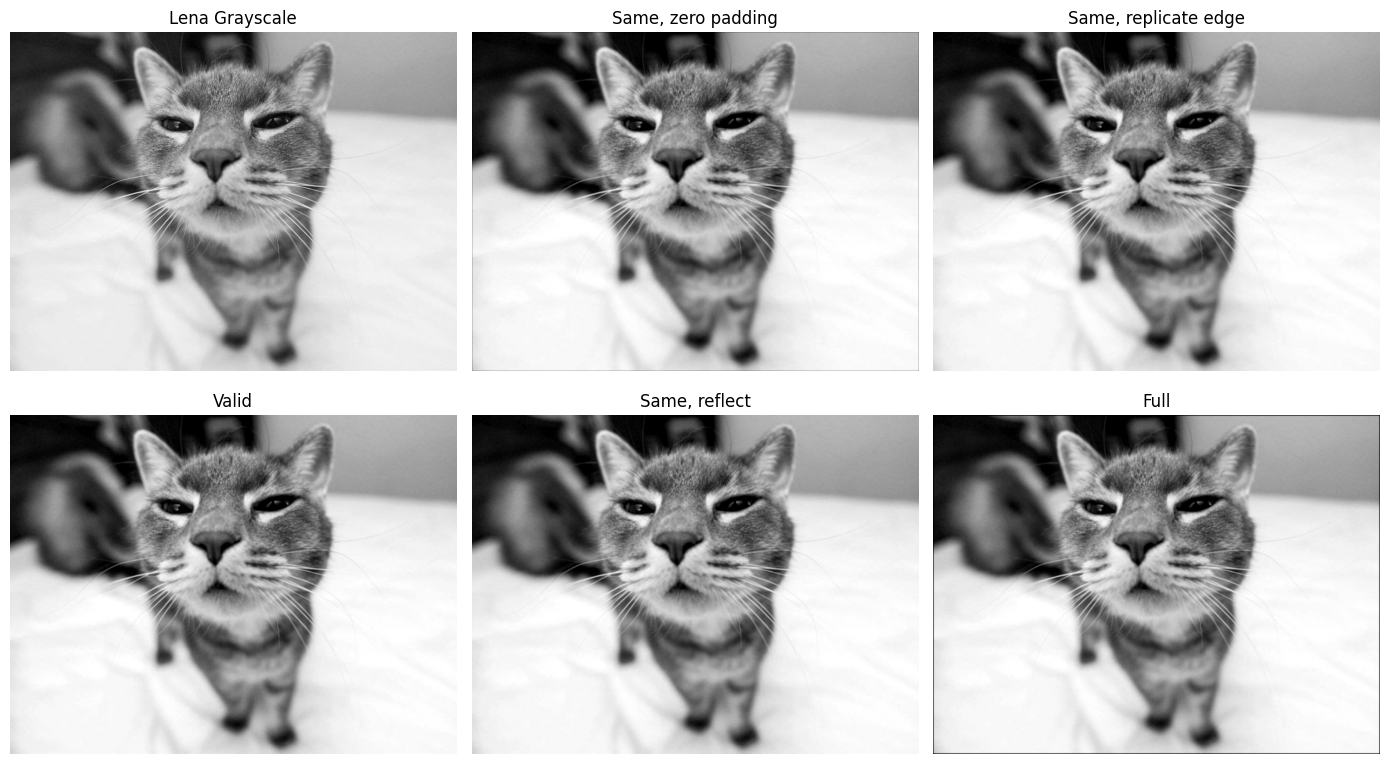

In [11]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ==== 1) Baca dan ubah ke grayscale 0..1 ====
img_rgb = Image.open("01.jpg").convert("RGB") # convert RGB to GRAY
arr = np.asarray(img_rgb).astype(np.float32) / 255.0
R, G, B = arr[...,0], arr[...,1], arr[...,2]
gray = 0.299*R + 0.587*G + 0.114*B   # luminance BT.601

print("Ukuran grayscale:", gray.shape)

# ==== 2) Kernel H sesuai contoh ====
H = np.array([[1, 1, 1],
              [1, 4, 1],
              [1, 1, 1]], dtype=np.float32)

# ==== 3) Fungsi konvolusi 2D manual (membalik kernel) ====
def conv2_valid(img, kernel):
    kh, kw = kernel.shape
    ih, iw = img.shape
    kflip = kernel[::-1, ::-1]
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow), dtype=np.float32)
    for i in range(oh):
        for j in range(ow):
            window = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kflip)
    return out

def conv2_same(img, kernel, pad_mode="constant"):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    if pad_mode == "replicate":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="edge")
    elif pad_mode == "reflect":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="reflect")
    else:
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="constant", constant_values=0.0)
    return conv2_valid(imgp, kernel)

def conv2_full(img, kernel):
    kh, kw = kernel.shape
    imgp = np.pad(img, ((kh-1, kh-1), (kw-1, kw-1)), mode="constant")
    return conv2_valid(imgp, kernel)

# ==== 4) Hitung keluaran ====
Y_valid = conv2_valid(gray, H)               # lebih kecil
Y_same0 = conv2_same(gray, H, "constant")    # ukuran sama, padding nol
Y_samerep = conv2_same(gray, H, "replicate") # ukuran sama, tepi direplikasi
Y_sameref = conv2_same(gray, H, "reflect")   # ukuran sama, refleksi
Y_full  = conv2_full(gray, H)                # lebih besar

print("valid:", Y_valid.shape, " same:", Y_same0.shape, " full:", Y_full.shape)

# ==== 5) Normalisasi opsional untuk ditampilkan ====
def norm01(x):
    x = x.astype(np.float32)
    m1, m2 = np.percentile(x, 1), np.percentile(x, 99)
    x = np.clip((x - m1) / (m2 - m1 + 1e-8), 0, 1)
    return x

# ==== 6) Visualisasi ====
plt.figure(figsize=(14,8))

plt.subplot(2,3,1); plt.imshow(gray, cmap="gray"); plt.title("Lena Grayscale"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(norm01(Y_same0), cmap="gray"); plt.title("Same, zero padding"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(norm01(Y_samerep), cmap="gray"); plt.title("Same, replicate edge"); plt.axis("off")

plt.subplot(2,3,5); plt.imshow(norm01(Y_sameref), cmap="gray"); plt.title("Same, reflect"); plt.axis("off")
plt.subplot(2,3,4); plt.imshow(norm01(Y_valid), cmap="gray"); plt.title("Valid"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(norm01(Y_full), cmap="gray"); plt.title("Full"); plt.axis("off")

plt.tight_layout()
plt.show()


In [12]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ==== 1) Baca dan ubah ke grayscale 0..1 ====
img_rgb = Image.open("01.png").convert("RGB")
arr = np.asarray(img_rgb).astype(np.float32) / 255.0
R, G, B = arr[...,0], arr[...,1], arr[...,2]
gray = 0.299*R + 0.587*G + 0.114*B   # luminance BT.601

print("Ukuran grayscale:", gray.shape)

# ==== 2) Kernel H sesuai contoh ====
H = np.array([[1, 1, 1],
              [1, 4, 1],
              [1, 1, 1]], dtype=np.float32)

H = 1/12 * H
# ==== 3) Fungsi konvolusi 2D manual (membalik kernel) ====
def conv2_valid(img, kernel):
    kh, kw = kernel.shape
    ih, iw = img.shape
    kflip = kernel[::-1, ::-1]
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow), dtype=np.float32)
    for i in range(oh):
        for j in range(ow):
            window = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kflip)
    return out

def conv2_same(img, kernel, pad_mode="constant"):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    if pad_mode == "replicate":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="edge")
    elif pad_mode == "reflect":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="reflect")
    else:
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="constant", constant_values=0.0)
    return conv2_valid(imgp, kernel)

def conv2_full(img, kernel):
    kh, kw = kernel.shape
    imgp = np.pad(img, ((kh-1, kh-1), (kw-1, kw-1)), mode="constant")
    return conv2_valid(imgp, kernel)

# ==== 4) Hitung keluaran ====
Y_valid = conv2_valid(gray, H)               # lebih kecil
Y_same0 = conv2_same(gray, H, "constant")    # ukuran sama, padding nol
Y_samerep = conv2_same(gray, H, "replicate") # ukuran sama, tepi direplikasi
Y_sameref = conv2_same(gray, H, "reflect")   # ukuran sama, refleksi
Y_full  = conv2_full(gray, H)                # lebih besar

print("valid:", Y_valid.shape, " same:", Y_same0.shape, " full:", Y_full.shape)

# ==== 5) Normalisasi opsional untuk ditampilkan ====
def norm01(x):
    x = x.astype(np.float32)
    m1, m2 = np.percentile(x, 1), np.percentile(x, 99)
    x = np.clip((x - m1) / (m2 - m1 + 1e-8), 0, 1)
    return x

# ==== 6) Visualisasi ====
plt.figure(figsize=(14,8))

plt.subplot(2,3,1); plt.imshow(gray, cmap="gray"); plt.title("Lena Grayscale"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(norm01(Y_same0), cmap="gray"); plt.title("Same, zero padding"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(norm01(Y_samerep), cmap="gray"); plt.title("Same, replicate edge"); plt.axis("off")

plt.subplot(2,3,5); plt.imshow(norm01(Y_sameref), cmap="gray"); plt.title("Same, reflect"); plt.axis("off")
plt.subplot(2,3,4); plt.imshow(norm01(Y_valid), cmap="gray"); plt.title("Valid"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(norm01(Y_full), cmap="gray"); plt.title("Full"); plt.axis("off")

plt.tight_layout()
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '01.png'

In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# ==== 1) Baca dan ubah ke grayscale 0..1 ====
img_rgb = Image.open("01.png").convert("RGB")
arr = np.asarray(img_rgb).astype(np.float32) / 255.0
R, G, B = arr[...,0], arr[...,1], arr[...,2]
gray = 0.299*R + 0.587*G + 0.114*B   # luminance BT.601

print("Ukuran grayscale:", gray.shape)

# ==== 2) Kernel H sesuai contoh ==== 
H = np.array([[-1, 0, 1],
              [-1, 0, 1],
              [-3, 0, 3]], dtype=np.float32)

# KERNEL HPF = 

# ==== 3) Fungsi konvolusi 2D manual (membalik kernel) ====
def conv2_valid(img, kernel):
    kh, kw = kernel.shape
    ih, iw = img.shape
    kflip = kernel[::-1, ::-1]
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow), dtype=np.float32)
    for i in range(oh):
        for j in range(ow):
            window = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kflip)
    return out

def conv2_same(img, kernel, pad_mode="constant"):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    if pad_mode == "replicate":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="edge")
    elif pad_mode == "reflect":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="reflect")
    else:
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="constant", constant_values=0.0)
    return conv2_valid(imgp, kernel)

def conv2_full(img, kernel):
    kh, kw = kernel.shape
    imgp = np.pad(img, ((kh-1, kh-1), (kw-1, kw-1)), mode="constant")
    return conv2_valid(imgp, kernel)

# ==== 4) Hitung keluaran ====
Y_valid = conv2_valid(gray, H)               # lebih kecil
Y_same0 = conv2_same(gray, H, "constant")    # ukuran sama, padding nol
Y_samerep = conv2_same(gray, H, "replicate") # ukuran sama, tepi direplikasi
Y_sameref = conv2_same(gray, H, "reflect")   # ukuran sama, refleksi
Y_full  = conv2_full(gray, H)                # lebih besar

print("valid:", Y_valid.shape, " same:", Y_same0.shape, " full:", Y_full.shape)

# ==== 5) Normalisasi opsional untuk ditampilkan ====
def norm01(x):
    x = x.astype(np.float32)
    m1, m2 = np.percentile(x, 1), np.percentile(x, 99)
    x = np.clip((x - m1) / (m2 - m1 + 1e-8), 0, 1)
    return x

# ==== 6) Visualisasi ====
plt.figure(figsize=(14,8))

plt.subplot(2,3,1); plt.imshow(gray, cmap="gray"); plt.title("Lena Grayscale"); plt.axis("off")
plt.subplot(2,3,2); plt.imshow(norm01(Y_same0), cmap="gray"); plt.title("Same, zero padding"); plt.axis("off")
plt.subplot(2,3,3); plt.imshow(norm01(Y_samerep), cmap="gray"); plt.title("Same, replicate edge"); plt.axis("off")

plt.subplot(2,3,5); plt.imshow(norm01(Y_sameref), cmap="gray"); plt.title("Same, reflect"); plt.axis("off")
plt.subplot(2,3,4); plt.imshow(norm01(Y_valid), cmap="gray"); plt.title("Valid"); plt.axis("off")
plt.subplot(2,3,6); plt.imshow(norm01(Y_full), cmap="gray"); plt.title("Full"); plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load & grayscale 0..1
# -----------------------------
img_rgb = Image.open("91.png").convert("RGB")
arr = np.asarray(img_rgb).astype(np.float32) / 255.0
R, G, B = arr[...,0], arr[...,1], arr[...,2]
gray = 0.299*R + 0.587*G + 0.114*B  # luminance BT.601

# -----------------------------
# 2) Tambahkan noise Gaussian
# -----------------------------
sigma = 0.1  # atur besaran noise (0.02 s.d. 0.1 umumnya cukup terlihat)
rng = np.random.default_rng(42)
noisy = np.clip(gray + rng.normal(0.0, sigma, size=gray.shape), 0.0, 1.0)

# -----------------------------
# 3) Kernel H dan conv2_same
# -----------------------------
H = np.array([[1, 1, 1],
              [1, 4, 1],
              [1, 1, 1]], dtype=np.float32)

H_norm = H / H.sum()  # normalisasi agar intensitas terjaga (jumlah=1) 1/12 * jumlah nilai kernel hasilnya pasti 1

def conv2_valid(img, kernel):
    kh, kw = kernel.shape
    ih, iw = img.shape
    kflip = kernel[::-1, ::-1]
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow), dtype=np.float32)
    for i in range(oh):
        for j in range(ow):
            window = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kflip)
    return out

def conv2_same(img, kernel, pad_mode="reflect"):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    if pad_mode == "replicate":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="edge")
    elif pad_mode == "constant":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="constant", constant_values=0.0)
    else:  # default: reflect (recommended for tepi)
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="reflect")
    return conv2_valid(imgp, kernel)

# -----------------------------
# 4) Konvolusi (SAME)
# -----------------------------
denoised = conv2_same(noisy, H_norm, pad_mode="reflect")

# -----------------------------
# 5) Metrik MSE & PSNR (opsional)
# -----------------------------
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def psnr(a, b, data_range=1.0):
    m = mse(a, b)
    if m == 0: return float('inf')
    return 10.0 * np.log10((data_range ** 2) / m)

print("MSE asli  vs asli :", mse(gray, gray))
print("PSNR asli vs asli :", psnr(gray, gray), "dB")
print("MSE noisy  vs asli :", mse(noisy, gray))
print("PSNR noisy vs asli :", psnr(noisy, gray), "dB")
print("MSE hasil  vs asli :", mse(denoised, gray))
print("PSNR hasil vs asli :", psnr(denoised, gray), "dB")

# -----------------------------
# 6) Visualisasi
# -----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap="gray");   plt.title("Lena (grayscale)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(noisy, cmap="gray");  plt.title(f"Noisy (σ={sigma})"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(denoised, cmap="gray"); plt.title("Conv2 SAME (H/12, reflect)"); plt.axis("off")
plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load & grayscale 0..1
# -----------------------------
img_rgb = Image.open("91.png").convert("RGB")
arr = np.asarray(img_rgb).astype(np.float32) / 255.0
R, G, B = arr[...,0], arr[...,1], arr[...,2]
gray = 0.299*R + 0.587*G + 0.114*B  # luminance BT.601

# -----------------------------
# 2) Tambahkan noise Gaussian
# -----------------------------
sigma = 0.1  # atur besaran noise (0.02 s.d. 0.1 umumnya cukup terlihat)
rng = np.random.default_rng(42)
noisy = np.clip(gray + rng.normal(0.0, sigma, size=gray.shape), 0.0, 1.0)

# -----------------------------
# 3) Kernel H dan conv2_same
# -----------------------------
H = np.array([[1, 2, 1],
              [2, 4, 2],
              [1, 2, 1]], dtype=np.float32)

H_norm = H / H.sum()  # normalisasi agar intensitas terjaga (jumlah=1) 1/12 * jumlah nilai kernel hasilnya pasti 1

def conv2_valid(img, kernel):
    kh, kw = kernel.shape
    ih, iw = img.shape
    kflip = kernel[::-1, ::-1]
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow), dtype=np.float32)
    for i in range(oh):
        for j in range(ow):
            window = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kflip)
    return out

def conv2_same(img, kernel, pad_mode="reflect"):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    if pad_mode == "replicate":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="edge")
    elif pad_mode == "constant":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="constant", constant_values=0.0)
    else:  # default: reflect (recommended for tepi)
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="reflect")
    return conv2_valid(imgp, kernel)

# -----------------------------
# 4) Konvolusi (SAME)
# -----------------------------
denoised = conv2_same(noisy, H_norm, pad_mode="reflect")

# -----------------------------
# 5) Metrik MSE & PSNR (opsional)
# -----------------------------
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def psnr(a, b, data_range=1.0):
    m = mse(a, b)
    if m == 0: return float('inf')
    return 10.0 * np.log10((data_range ** 2) / m)

print("MSE asli  vs asli :", mse(gray, gray))
print("PSNR asli vs asli :", psnr(gray, gray), "dB")
print("MSE noisy  vs asli :", mse(noisy, gray))
print("PSNR noisy vs asli :", psnr(noisy, gray), "dB")
print("MSE hasil  vs asli :", mse(denoised, gray))
print("PSNR hasil vs asli :", psnr(denoised, gray), "dB")

# -----------------------------
# 6) Visualisasi
# -----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap="gray");   plt.title("Lena (grayscale)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(noisy, cmap="gray");  plt.title(f"Noisy (σ={sigma})"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(denoised, cmap="gray"); plt.title("Conv2 SAME (H/12, reflect)"); plt.axis("off")
plt.tight_layout(); plt.show()


In [ ]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# -----------------------------
# 1) Load & grayscale 0..1
# -----------------------------
img_rgb = Image.open("01.png").convert("RGB")
arr = np.asarray(img_rgb).astype(np.float32) / 255.0
R, G, B = arr[...,0], arr[...,1], arr[...,2]
gray = 0.299*R + 0.587*G + 0.114*B  # luminance BT.601

# -----------------------------
# 2) Tambahkan noise Gaussian
# -----------------------------
sigma = 0.1  # atur besaran noise (0.02 s.d. 0.1 umumnya cukup terlihat)
rng = np.random.default_rng(42)
noisy = np.clip(gray + rng.normal(0.0, sigma, size=gray.shape), 0.0, 1.0)

# -----------------------------
# 3) Kernel H dan conv2_same
# -----------------------------
H_norm = np.array([[0, -1, 0],
              [-1, 5, -1],
              [0, -1, 0]], dtype=np.float32)

# H_norm = H / H.sum()  # normalisasi agar intensitas terjaga (jumlah=1) 1/12 * jumlah nilai kernel hasilnya pasti 1

def conv2_valid(img, kernel):
    kh, kw = kernel.shape
    ih, iw = img.shape
    kflip = kernel[::-1, ::-1]
    oh, ow = ih - kh + 1, iw - kw + 1
    out = np.zeros((oh, ow), dtype=np.float32)
    for i in range(oh):
        for j in range(ow):
            window = img[i:i+kh, j:j+kw]
            out[i, j] = np.sum(window * kflip)
    return out

def conv2_same(img, kernel, pad_mode="reflect"):
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    if pad_mode == "replicate":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="edge")
    elif pad_mode == "constant":
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="constant", constant_values=0.0)
    else:  # default: reflect (recommended for tepi)
        imgp = np.pad(img, ((ph, ph), (pw, pw)), mode="reflect")
    return conv2_valid(imgp, kernel)

# -----------------------------
# 4) Konvolusi (SAME)
# -----------------------------
denoised = conv2_same(noisy, H_norm, pad_mode="reflect")

# -----------------------------
# 5) Metrik MSE & PSNR (opsional)
# -----------------------------
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def psnr(a, b, data_range=1.0):
    m = mse(a, b)
    if m == 0: return float('inf')
    return 10.0 * np.log10((data_range ** 2) / m)

print("MSE asli  vs asli :", mse(gray, gray))
print("PSNR asli vs asli :", psnr(gray, gray), "dB")
print("MSE noisy  vs asli :", mse(noisy, gray))
print("PSNR noisy vs asli :", psnr(noisy, gray), "dB")
print("MSE hasil  vs asli :", mse(denoised, gray))
print("PSNR hasil vs asli :", psnr(denoised, gray), "dB")

# -----------------------------
# 6) Visualisasi
# -----------------------------
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(gray, cmap="gray");   plt.title("Lena (grayscale)"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(noisy, cmap="gray");  plt.title(f"Noisy (σ={sigma})"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(denoised, cmap="gray"); plt.title("Conv2 SAME (H/12, reflect)"); plt.axis("off")
plt.tight_layout(); plt.show()
